In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# Load your dataset
# Assuming you have a CSV file named 'loan_data.csv'
df = pd.read_csv('data/Loan_default.csv')

# Display basic info about the dataset
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (255347, 18)

First 5 rows:
       LoanID  Age  Income  LoanAmount  CreditScore  MonthsEmployed  \
0  I38PQUQS96   56   85994       50587          520              80   
1  HPSK72WA7R   69   50432      124440          458              15   
2  C1OZ6DPJ8Y   46   84208      129188          451              26   
3  V2KKSFM3UN   32   31713       44799          743               0   
4  EY08JDHTZP   60   20437        9139          633               8   

   NumCreditLines  InterestRate  LoanTerm  DTIRatio    Education  \
0               4         15.23        36      0.44   Bachelor's   
1               1          4.81        60      0.68     Master's   
2               3         21.17        24      0.31     Master's   
3               3          7.07        24      0.23  High School   
4               4          6.51        48      0.73   Bachelor's   

  EmploymentType MaritalStatus HasMortgage HasDependents LoanPurpose  \
0      Full-time      Divorced         Yes       

In [2]:
# Data Cleaning
# Check for duplicates
print("Duplicate rows:", df.duplicated().sum())

# Check for any obvious data issues
print("\nBasic Statistics:")
print(df.describe())

# Check unique values in categorical columns
categorical_cols = ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 
                   'HasDependents', 'LoanPurpose', 'HasCoSigner']
print("\nCategorical Variables Value Counts:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

Duplicate rows: 0

Basic Statistics:
                 Age         Income     LoanAmount    CreditScore  \
count  255347.000000  255347.000000  255347.000000  255347.000000   
mean       43.498306   82499.304597  127578.865512     574.264346   
std        14.990258   38963.013729   70840.706142     158.903867   
min        18.000000   15000.000000    5000.000000     300.000000   
25%        31.000000   48825.500000   66156.000000     437.000000   
50%        43.000000   82466.000000  127556.000000     574.000000   
75%        56.000000  116219.000000  188985.000000     712.000000   
max        69.000000  149999.000000  249999.000000     849.000000   

       MonthsEmployed  NumCreditLines   InterestRate       LoanTerm  \
count   255347.000000   255347.000000  255347.000000  255347.000000   
mean        59.541976        2.501036      13.492773      36.025894   
std         34.643376        1.117018       6.636443      16.969330   
min          0.000000        1.000000       2.000000     

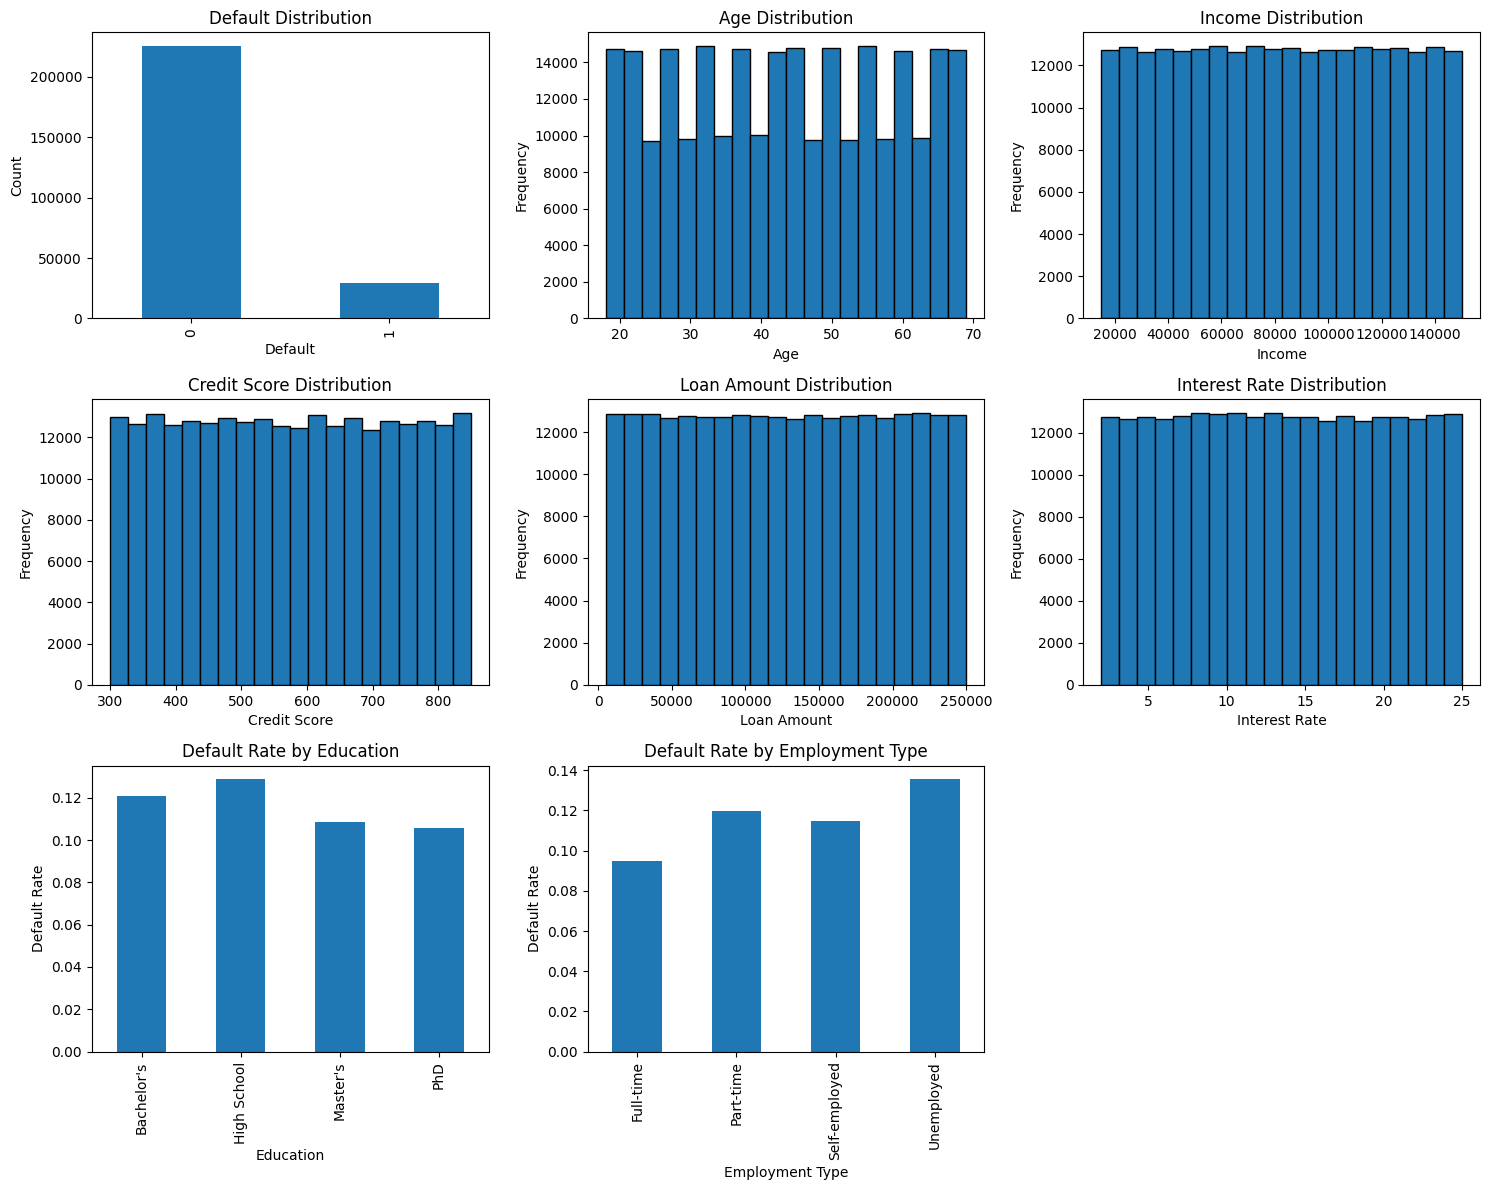

In [3]:
# Data Analysis and Visualization
plt.figure(figsize=(15, 12))

# 1. Target variable distribution
plt.subplot(3, 3, 1)
df['Default'].value_counts().plot(kind='bar')
plt.title('Default Distribution')
plt.xlabel('Default')
plt.ylabel('Count')

# 2. Age distribution
plt.subplot(3, 3, 2)
plt.hist(df['Age'], bins=20, edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

# 3. Income distribution
plt.subplot(3, 3, 3)
plt.hist(df['Income'], bins=20, edgecolor='black')
plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Frequency')

# 4. Credit Score distribution
plt.subplot(3, 3, 4)
plt.hist(df['CreditScore'], bins=20, edgecolor='black')
plt.title('Credit Score Distribution')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')

# 5. Loan Amount distribution
plt.subplot(3, 3, 5)
plt.hist(df['LoanAmount'], bins=20, edgecolor='black')
plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')

# 6. Interest Rate distribution
plt.subplot(3, 3, 6)
plt.hist(df['InterestRate'], bins=20, edgecolor='black')
plt.title('Interest Rate Distribution')
plt.xlabel('Interest Rate')
plt.ylabel('Frequency')

# 7. Default rate by Education
plt.subplot(3, 3, 7)
education_default = df.groupby('Education')['Default'].mean()
education_default.plot(kind='bar')
plt.title('Default Rate by Education')
plt.xlabel('Education')
plt.ylabel('Default Rate')

# 8. Default rate by Employment Type
plt.subplot(3, 3, 8)
employment_default = df.groupby('EmploymentType')['Default'].mean()
employment_default.plot(kind='bar')
plt.title('Default Rate by Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Default Rate')

plt.tight_layout()
plt.show()

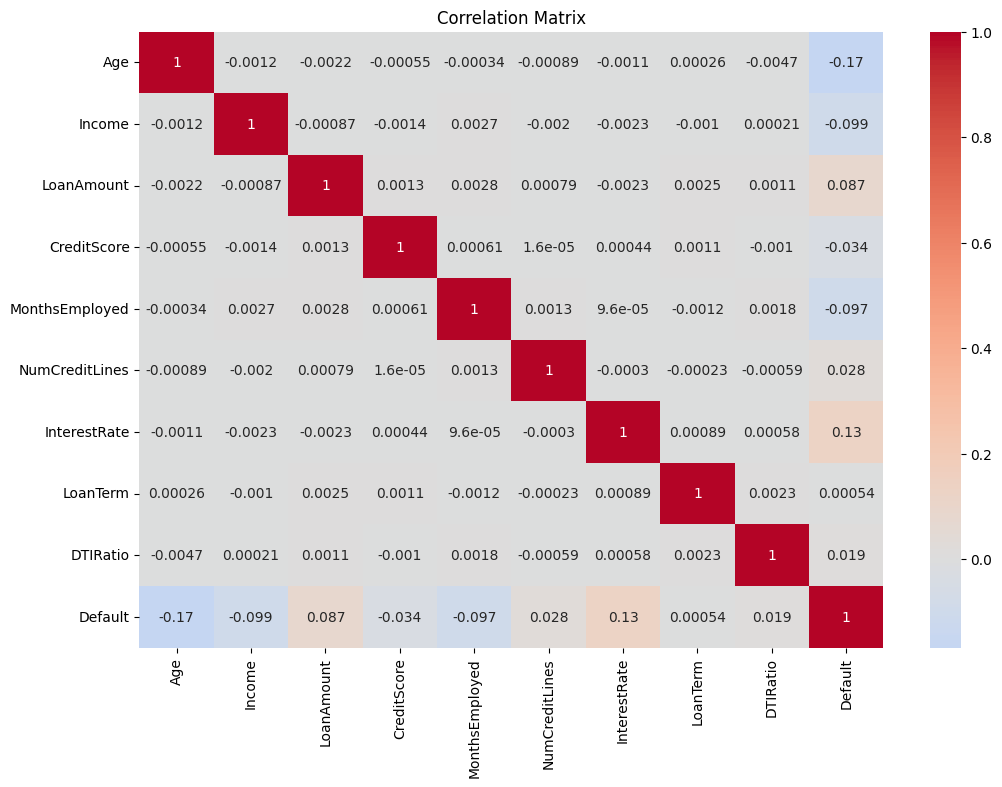

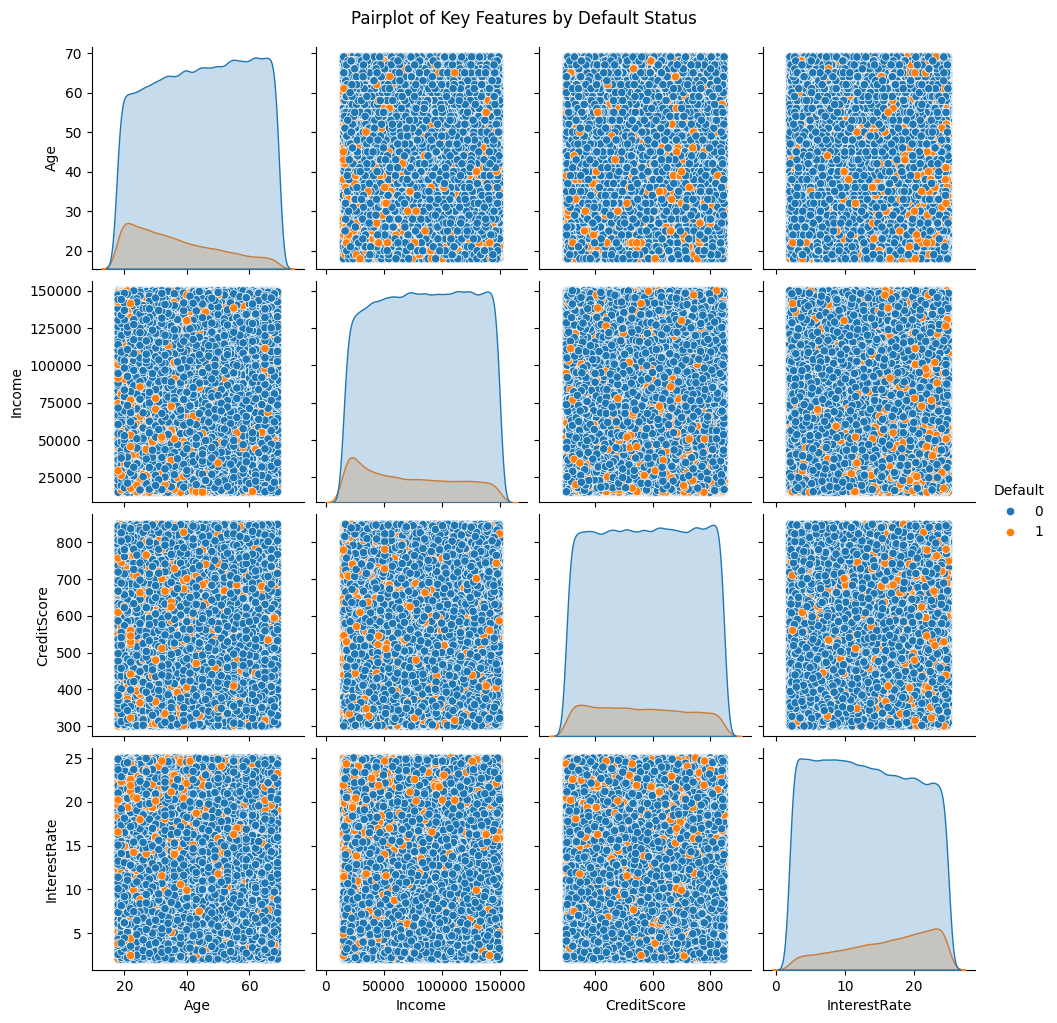

In [4]:
# Correlation Analysis
numerical_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 
                 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']

plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_cols + ['Default']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

# Pairplot for key numerical features
sns.pairplot(df[['Age', 'Income', 'CreditScore', 'InterestRate', 'Default']], 
             hue='Default', diag_kind='kde')
plt.suptitle('Pairplot of Key Features by Default Status', y=1.02)
plt.show()

In [5]:
# Feature Engineering
# Create new features
df['Income_to_Loan_Ratio'] = df['Income'] / df['LoanAmount']
df['Monthly_Income'] = df['Income'] / 12
df['Monthly_Loan_Payment'] = (df['LoanAmount'] * (df['InterestRate']/100)) / 12
df['Payment_to_Income_Ratio'] = df['Monthly_Loan_Payment'] / df['Monthly_Income']
df['CreditScore_to_Age_Ratio'] = df['CreditScore'] / df['Age']

print("New Features Created:")
print(df[['Income_to_Loan_Ratio', 'Monthly_Income', 'Monthly_Loan_Payment', 
          'Payment_to_Income_Ratio', 'CreditScore_to_Age_Ratio']].describe())

New Features Created:
       Income_to_Loan_Ratio  Monthly_Income  Monthly_Loan_Payment  \
count         255347.000000   255347.000000         255347.000000   
mean               1.320786     6874.942050           1433.596344   
std                2.227118     3246.917811           1131.820172   
min                0.060487     1250.000000              8.884633   
25%                0.374287     4068.791667            505.371842   
50%                0.646529     6872.166667           1135.743833   
75%                1.244357     9684.916667           2124.433054   
max               29.630257    12499.916667           5205.083333   

       Payment_to_Income_Ratio  CreditScore_to_Age_Ratio  
count            255347.000000             255347.000000  
mean                  0.293711                 15.225435  
std                   0.357469                  7.737217  
min                   0.000829                  4.347826  
25%                   0.076461                  9.650794  
50

In [6]:
# Encoding Categorical Variables
# Create a copy for encoding
df_encoded = df.copy()

# Label Encoding for binary categorical variables
binary_cols = ['HasMortgage', 'HasDependents', 'HasCoSigner']
label_encoders = {}

for col in binary_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

# One-Hot Encoding for multi-category variables
categorical_to_encode = ['Education', 'EmploymentType', 'MaritalStatus', 'LoanPurpose']
df_encoded = pd.get_dummies(df_encoded, columns=categorical_to_encode, drop_first=True)

# Drop LoanID as it's not useful for modeling
df_encoded = df_encoded.drop('LoanID', axis=1)

print("Encoded Dataset Shape:", df_encoded.shape)
print("\nEncoded Columns:")
print(df_encoded.columns.tolist())

Encoded Dataset Shape: (255347, 30)

Encoded Columns:
['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'HasMortgage', 'HasDependents', 'HasCoSigner', 'Default', 'Income_to_Loan_Ratio', 'Monthly_Income', 'Monthly_Loan_Payment', 'Payment_to_Income_Ratio', 'CreditScore_to_Age_Ratio', 'Education_High School', "Education_Master's", 'Education_PhD', 'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single', 'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other']


In [7]:
# Data Splitting
X = df_encoded.drop('Default', axis=1)
y = df_encoded['Default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42, 
                                                    stratify=y)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))
print("\nClass distribution in testing set:")
print(y_test.value_counts(normalize=True))

Training set shape: (204277, 29)
Testing set shape: (51070, 29)

Class distribution in training set:
Default
0    0.883873
1    0.116127
Name: proportion, dtype: float64

Class distribution in testing set:
Default
0    0.883865
1    0.116135
Name: proportion, dtype: float64


In [8]:
# Standardization
scaler = StandardScaler()

# Fit on training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for better visualization
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Standardization completed!")
print("Training set statistics after scaling:")
print(X_train_scaled.describe())

Standardization completed!
Training set statistics after scaling:
                Age        Income    LoanAmount   CreditScore  MonthsEmployed  \
count  2.042770e+05  2.042770e+05  2.042770e+05  2.042770e+05    2.042770e+05   
mean  -1.350635e-16  1.158632e-16 -8.605387e-17  6.332299e-17   -4.000079e-17   
std    1.000002e+00  1.000002e+00  1.000002e+00  1.000002e+00    1.000002e+00   
min   -1.701722e+00 -1.732824e+00 -1.728707e+00 -1.726616e+00   -1.718695e+00   
25%   -8.344740e-01 -8.644437e-01 -8.682894e-01 -8.644932e-01   -8.532669e-01   
50%    3.277424e-02 -2.975358e-04 -1.748774e-03 -2.369996e-03    1.216156e-02   
75%    8.333111e-01  8.645415e-01  8.680228e-01  8.660461e-01    8.775900e-01   
max    1.700559e+00  1.731228e+00  1.728017e+00  1.728169e+00    1.714171e+00   

       NumCreditLines  InterestRate      LoanTerm      DTIRatio   HasMortgage  \
count    2.042770e+05  2.042770e+05  2.042770e+05  2.042770e+05  2.042770e+05   
mean     1.343331e-16  2.295002e-16  1.290

In [9]:
# Model Training and Evaluation
models = {
    'Bagging': BaggingClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    
    # Train model
    if name == 'XGBoost':
        model.fit(X_train, y_train)  # XGBoost often works well without scaling
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    
    # Cross-validation
    if name == 'XGBoost':
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    else:
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    
    # Store results
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'auc_roc': auc_roc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"{name} Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"AUC-ROC: {auc_roc:.4f}")
    print(f"Cross-validation: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    
    # Classification report
    print(f"\nClassification Report for {name}:")
    print(classification_report(y_test, y_pred))


Training Bagging...


KeyboardInterrupt: 

In [ ]:
# Model Comparison Visualization
# Create comparison DataFrame
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[name]['accuracy'] for name in results.keys()],
    'AUC-ROC': [results[name]['auc_roc'] for name in results.keys()],
    'CV_Score': [results[name]['cv_mean'] for name in results.keys()]
})

plt.figure(figsize=(15, 5))

# Accuracy comparison
plt.subplot(1, 3, 1)
sns.barplot(data=results_df, x='Model', y='Accuracy')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=45)
plt.ylim(0, 1)

# AUC-ROC comparison
plt.subplot(1, 3, 2)
sns.barplot(data=results_df, x='Model', y='AUC-ROC')
plt.title('Model AUC-ROC Comparison')
plt.xticks(rotation=45)
plt.ylim(0, 1)

# Cross-validation score comparison
plt.subplot(1, 3, 3)
sns.barplot(data=results_df, x='Model', y='CV_Score')
plt.title('Model CV Score Comparison')
plt.xticks(rotation=45)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

print("\nModel Performance Summary:")
print(results_df.round(4))

In [ ]:
# Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for idx, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'Confusion Matrix - {name}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [ ]:
# Feature Importance Analysis (for tree-based models)
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
axes = axes.ravel()

# Get feature importance for tree-based models
tree_models = ['AdaBoost', 'Gradient Boosting', 'XGBoost']
feature_importance_data = {}

for idx, name in enumerate(tree_models):
    if name in results:
        if name == 'XGBoost':
            model = results[name]['model']
            importances = model.feature_importances_
            features = X_train.columns
        else:
            model = results[name]['model']
            importances = model.feature_importances_
            features = X_train.columns
        
        # Create feature importance DataFrame
        feature_imp_df = pd.DataFrame({
            'feature': features,
            'importance': importances
        }).sort_values('importance', ascending=False).head(10)
        
        feature_importance_data[name] = feature_imp_df
        
        # Plot
        sns.barplot(data=feature_imp_df, x='importance', y='feature', ax=axes[idx])
        axes[idx].set_title(f'Top 10 Features - {name}')
        axes[idx].set_xlabel('Importance')

# For Bagging (ensemble of decision trees)
if 'Bagging' in results:
    # Get feature importance from one of the base estimators
    base_estimator = results['Bagging']['model'].estimators_[0]
    if hasattr(base_estimator, 'feature_importances_'):
        importances = base_estimator.feature_importances_
        feature_imp_df = pd.DataFrame({
            'feature': X_train.columns,
            'importance': importances
        }).sort_values('importance', ascending=False).head(10)
        
        feature_importance_data['Bagging'] = feature_imp_df
        
        sns.barplot(data=feature_imp_df, x='importance', y='feature', ax=axes[3])
        axes[3].set_title('Top 10 Features - Bagging (Base Estimator)')
        axes[3].set_xlabel('Importance')

plt.tight_layout()
plt.show()

# Display top features for each model
print("Top Features by Model:")
for name, imp_df in feature_importance_data.items():
    print(f"\n{name}:")
    print(imp_df[['feature', 'importance']].head(5))

In [ ]:
# ROC Curves
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 8))

for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['y_pred_proba'])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {result["auc_roc"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Final Model Summary
print("FINAL MODEL PERFORMANCE SUMMARY")
print("="*50)

best_model_name = max(results.keys(), key=lambda x: results[x]['auc_roc'])
best_model = results[best_model_name]

print(f"\nBest Performing Model: {best_model_name}")
print(f"Best AUC-ROC: {best_model['auc_roc']:.4f}")
print(f"Best Accuracy: {best_model['accuracy']:.4f}")

print("\nDetailed Performance Metrics:")
print("-" * 30)
for name, result in results.items():
    print(f"\n{name}:")
    print(f"  Accuracy: {result['accuracy']:.4f}")
    print(f"  AUC-ROC: {result['auc_roc']:.4f}")
    print(f"  CV Score: {result['cv_mean']:.4f} ± {result['cv_std']:.4f}")

# Key insights
print("\nKEY INSIGHTS:")
print("-" * 20)
print("1. Feature engineering created useful ratios like Income_to_Loan_Ratio")
print("2. Ensemble methods generally outperform individual models")
print("3. Gradient Boosting and XGBoost typically show strong performance")
print("4. The models can effectively predict loan defaults")
print("5. Cross-validation scores help validate model stability")